In [129]:
import pandas as pd
import numpy as np
import seaborn as sns
from zmq.backend.cffi.socket import new_binary_data



## EDA

In [73]:
mpg = pd.read_csv("auto-mpg.csv")
mpg.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,car name
0,18.0,8,307.0,130,3504,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165,3693,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150,3436,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150,3433,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140,3449,10.5,70,1,ford torino


In [74]:
mpg.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    398 non-null    object 
 4   weight        398 non-null    int64  
 5   acceleration  398 non-null    float64
 6   model year    398 non-null    int64  
 7   origin        398 non-null    int64  
 8   car name      398 non-null    object 
dtypes: float64(3), int64(4), object(2)
memory usage: 28.1+ KB


In [75]:
mpg['origin'] = mpg['origin'].astype('object')

In [76]:
mpg['horsepower'].unique()

array(['130', '165', '150', '140', '198', '220', '215', '225', '190',
       '170', '160', '95', '97', '85', '88', '46', '87', '90', '113',
       '200', '210', '193', '?', '100', '105', '175', '153', '180', '110',
       '72', '86', '70', '76', '65', '69', '60', '80', '54', '208', '155',
       '112', '92', '145', '137', '158', '167', '94', '107', '230', '49',
       '75', '91', '122', '67', '83', '78', '52', '61', '93', '148',
       '129', '96', '71', '98', '115', '53', '81', '79', '120', '152',
       '102', '108', '68', '58', '149', '89', '63', '48', '66', '139',
       '103', '125', '133', '138', '135', '142', '77', '62', '132', '84',
       '64', '74', '116', '82'], dtype=object)

In [77]:
mpg.query("horsepower =='?'")

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,car name
32,25.0,4,98.0,?,2046,19.0,71,1,ford pinto
126,21.0,6,200.0,?,2875,17.0,74,1,ford maverick
330,40.9,4,85.0,?,1835,17.3,80,2,renault lecar deluxe
336,23.6,4,140.0,?,2905,14.3,80,1,ford mustang cobra
354,34.5,4,100.0,?,2320,15.8,81,2,renault 18i
374,23.0,4,151.0,?,3035,20.5,82,1,amc concord dl


In [78]:
mpg['horsepower'] = pd.to_numeric(mpg['horsepower'], errors='coerce')
mpg['horsepower'] = mpg['horsepower'].fillna(mpg['horsepower'].mean())

In [79]:
mpg.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    398 non-null    float64
 4   weight        398 non-null    int64  
 5   acceleration  398 non-null    float64
 6   model year    398 non-null    int64  
 7   origin        398 non-null    object 
 8   car name      398 non-null    object 
dtypes: float64(4), int64(3), object(2)
memory usage: 28.1+ KB


In [80]:
mpg.describe()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year
count,398.000000,398.000000,398.000000,398.000000,398.000000,398.000000,398.000000
mean,23.514573,5.454774,193.425879,104.469388,2970.424623,15.568090,76.010050
std,7.815984,1.701004,104.269838,38.199187,846.841774,2.757689,3.697627
min,9.000000,3.000000,68.000000,46.000000,1613.000000,8.000000,70.000000
25%,17.500000,4.000000,104.250000,76.000000,2223.750000,13.825000,73.000000
50%,23.000000,4.000000,148.500000,95.000000,2803.500000,15.500000,76.000000
75%,29.000000,8.000000,262.000000,125.000000,3608.000000,17.175000,79.000000
max,46.600000,8.000000,455.000000,230.000000,5140.000000,24.800000,82.000000


<Axes: xlabel='mpg', ylabel='Count'>

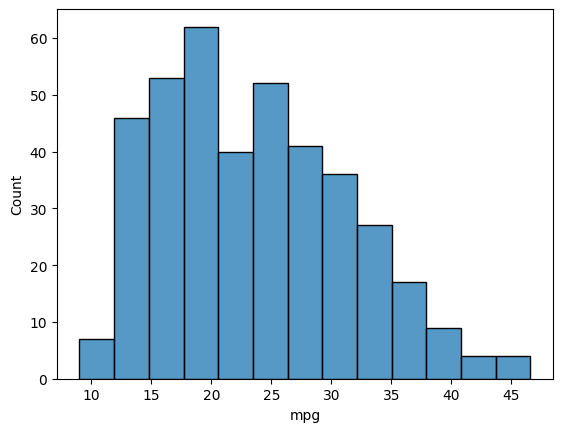

In [81]:
sns.histplot(mpg['mpg'])

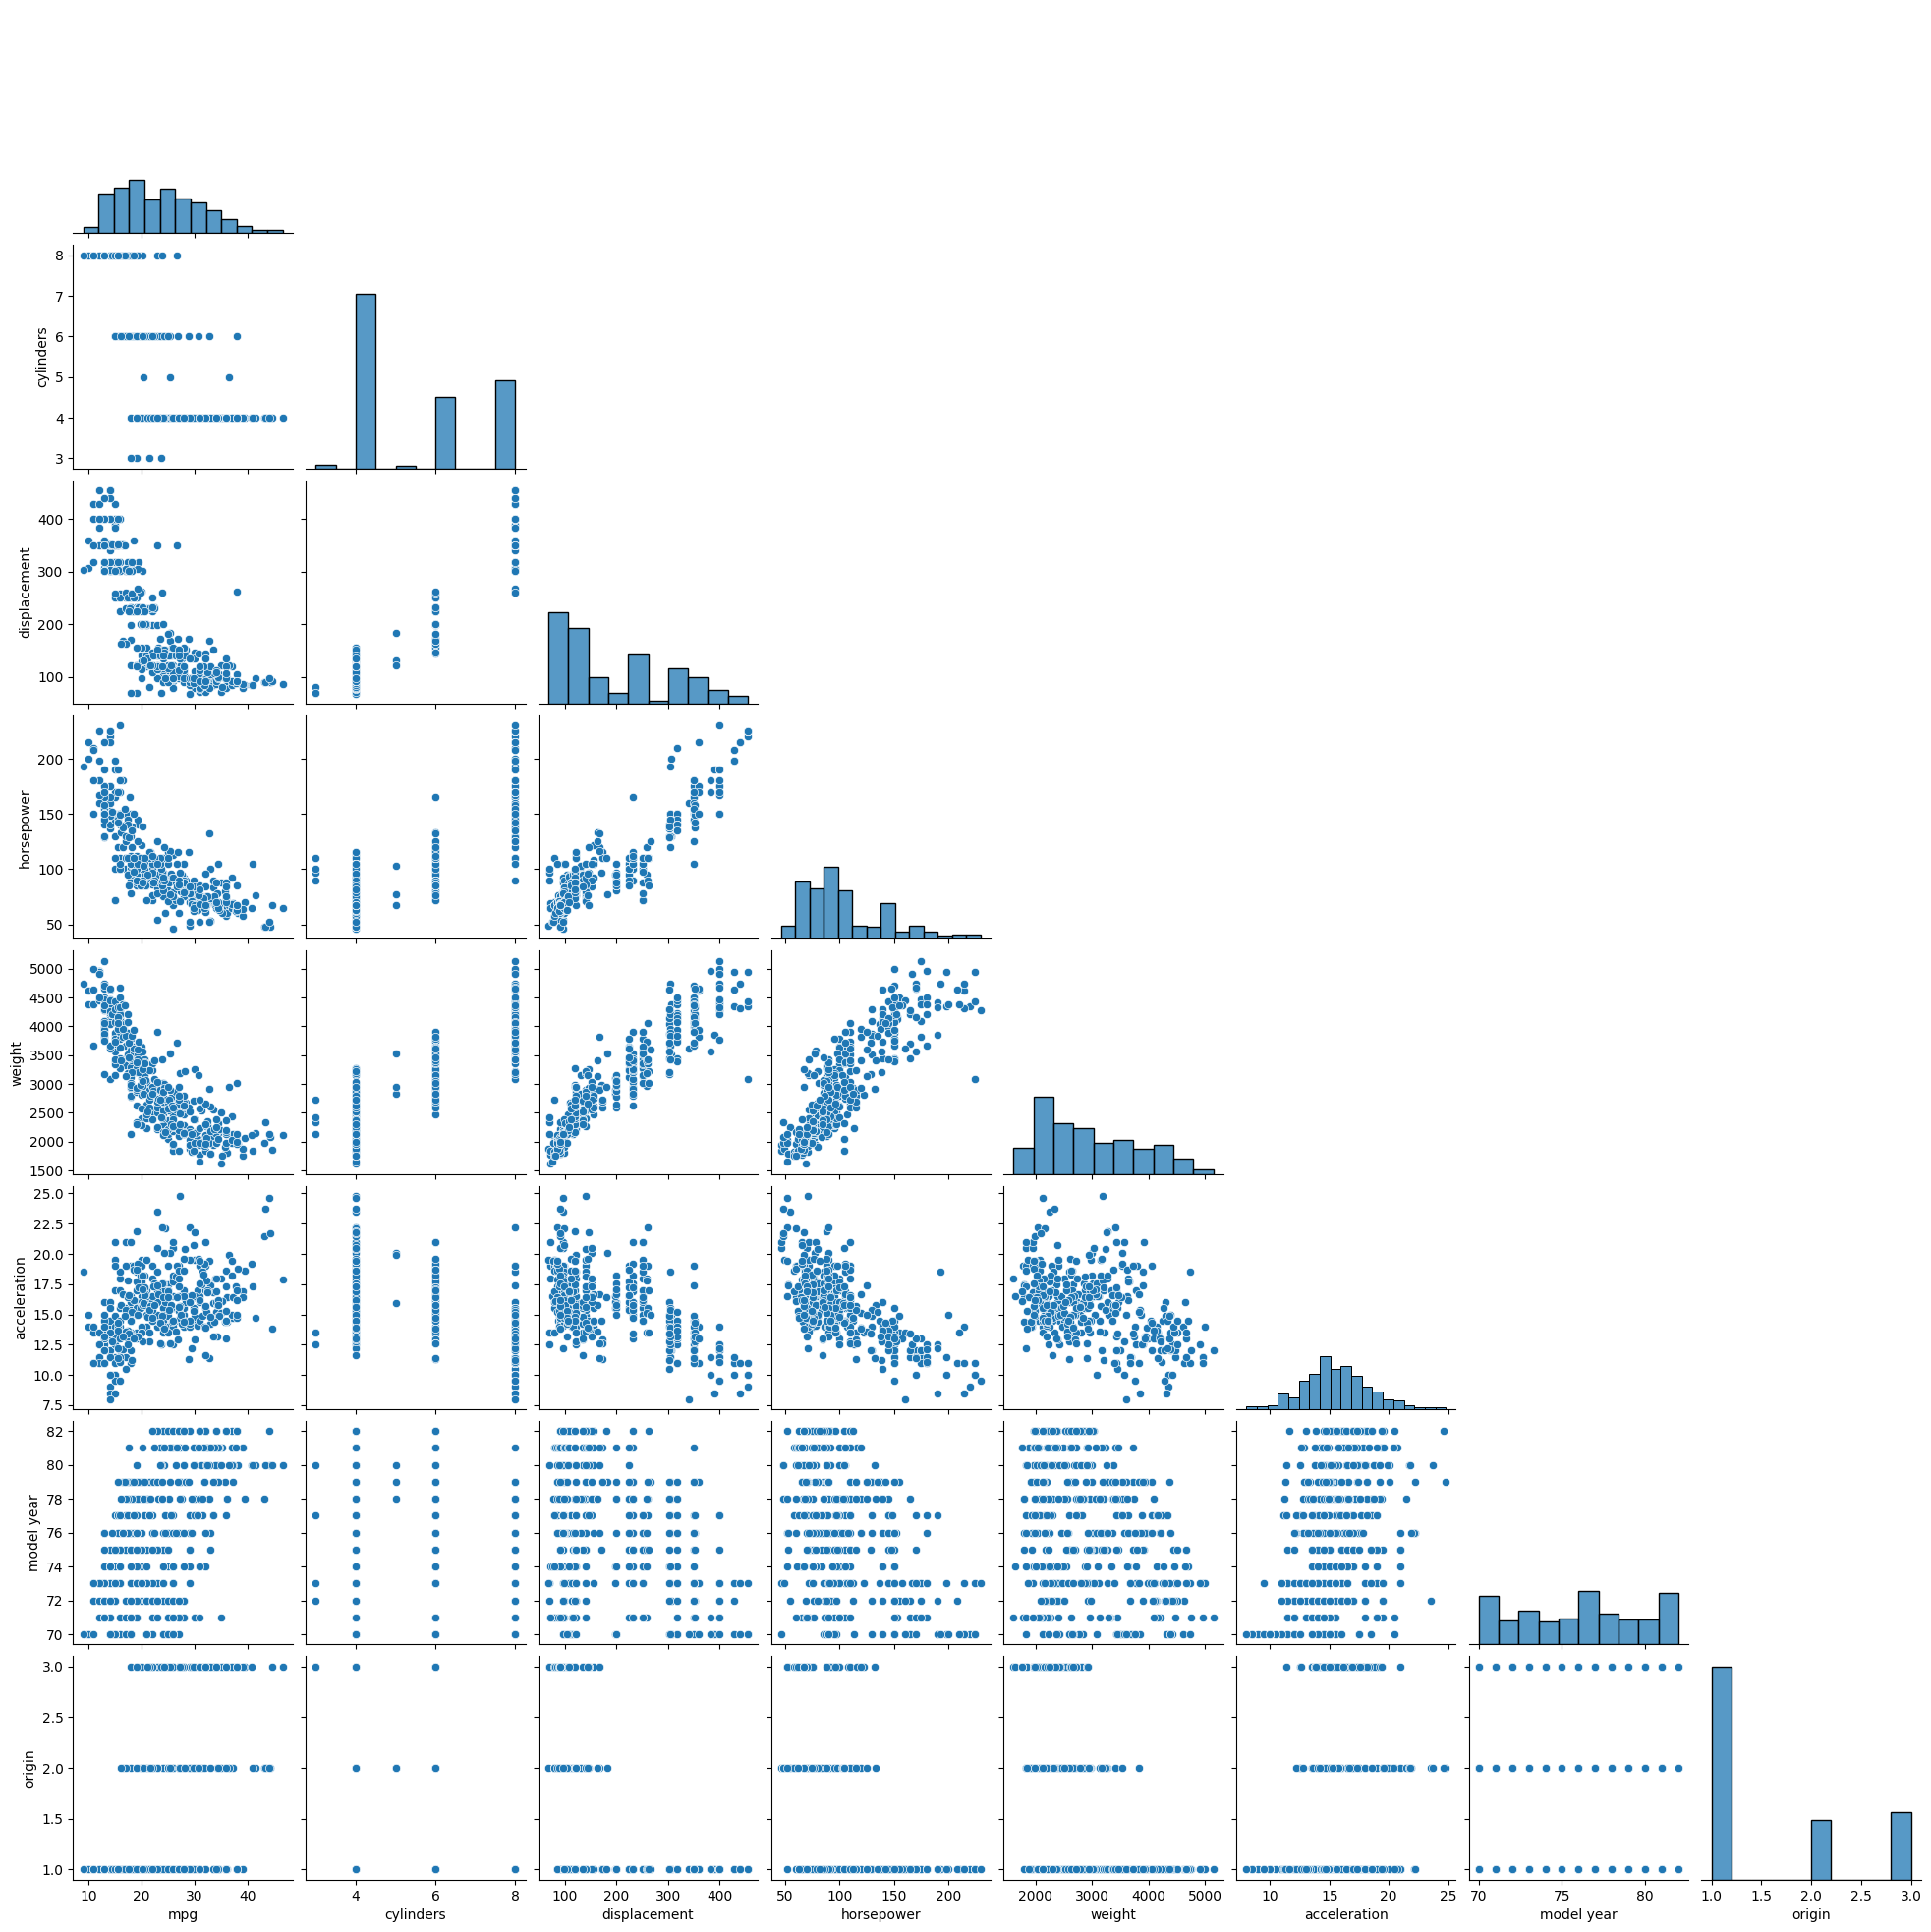

In [16]:
sns.pairplot(mpg,corner=True)

<Axes: xlabel='origin', ylabel='mpg'>

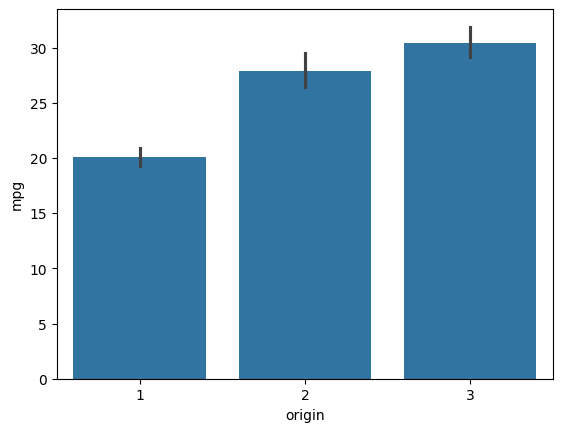

In [82]:
sns.barplot(data=mpg,x='origin',y='mpg')

In [84]:
mpg.corr(numeric_only=True)

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year
mpg,1.000000,-0.775396,-0.804203,-0.771437,-0.831741,0.420289,0.579267
cylinders,-0.775396,1.000000,0.950721,0.838939,0.896017,-0.505419,-0.348746
displacement,-0.804203,0.950721,1.000000,0.893646,0.932824,-0.543684,-0.370164
horsepower,-0.771437,0.838939,0.893646,1.000000,0.860574,-0.684259,-0.411651
weight,-0.831741,0.896017,0.932824,0.860574,1.000000,-0.417457,-0.306564
acceleration,0.420289,-0.505419,-0.543684,-0.684259,-0.417457,1.000000,0.288137
model year,0.579267,-0.348746,-0.370164,-0.411651,-0.306564,0.288137,1.000000


<Axes: >

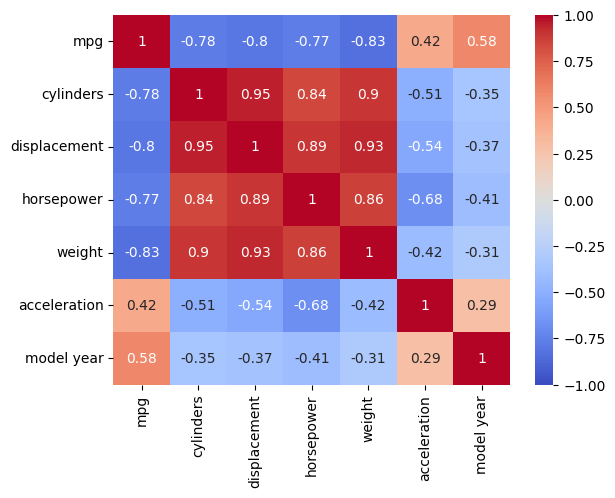

In [85]:
sns.heatmap(mpg.corr(numeric_only=True),
            vmin=-1,
            vmax=1,
            cmap='coolwarm',
            annot=True)

## Building the Linear Regression Model

In [88]:
from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold
from sklearn.metrics import r2_score as r2, mean_absolute_error as mae
import statsmodels.api as sm


In [89]:
mpg_model = mpg.assign(
    weight2 = mpg['weight']**2
).drop("car name", axis=1)

mpg_model = pd.get_dummies(mpg_model, drop_first=True)


In [90]:
mpg_model.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,weight2,origin_2,origin_3
0,18.0,8,307.0,130.0,3504,12.0,70,12278016,False,False
1,15.0,8,350.0,165.0,3693,11.5,70,13638249,False,False
2,18.0,8,318.0,150.0,3436,11.0,70,11806096,False,False
3,16.0,8,304.0,150.0,3433,12.0,70,11785489,False,False
4,17.0,8,302.0,140.0,3449,10.5,70,11895601,False,False


In [150]:
features = ['weight',
            'weight2',
  #          'cylinders',
   #         'displacement',
    #        'horsepower',
     #       'acceleration',
      #    'model year',
       #     'origin_2',
        #    'origin_3'
        ]

X = sm.add_constant(mpg_model[features])
y = mpg_model['mpg']

X,X_test, y, y_test = train_test_split(X, y, test_size=0.2, random_state=2023)


In [109]:
mpg_model['origin_2'] = mpg_model['origin_2'].astype('float')
mpg_model['origin_3'] = mpg_model['origin_3'].astype('float')

mpg_model.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    398 non-null    float64
 4   weight        398 non-null    int64  
 5   acceleration  398 non-null    float64
 6   model year    398 non-null    int64  
 7   weight2       398 non-null    int64  
 8   origin_2      398 non-null    float64
 9   origin_3      398 non-null    float64
dtypes: float64(6), int64(4)
memory usage: 31.2 KB


In [151]:
print(X.dtypes)
print(y.dtypes)


const      float64
weight       int64
weight2      int64
dtype: object
float64


In [152]:
kf = KFold(n_splits=5, shuffle=True, random_state=2023)

cv_lr_r2s = []
cv_lr_mae = []

for train_ind, val_ind in kf.split(X, y):
    X_train, y_train = X.iloc[train_ind], y.iloc[train_ind]
    X_val, y_val =  X.iloc[val_ind], y.iloc[val_ind]

    model = sm.OLS(y_train, X_train).fit()

    cv_lr_r2s.append(r2(y_val, model.predict(X_val),))
    cv_lr_mae.append(mae(y_val, model.predict(X_val),))

print("All validation R2's:", [round(x,3) for x in cv_lr_r2s])
print(f"Cross val R2's: {round(np.mean(cv_lr_r2s),3)} +- {round(np.std(cv_lr_r2s),3)}")

print("All validation MAEs:", [round(x,3) for x in cv_lr_mae])
print(f"Cross val MAE: {round(np.mean(cv_lr_mae),3)}  +- {round(np.std(cv_lr_mae),3)}")

All validation R2's: [0.805, 0.737, 0.653, 0.631, 0.697]
Cross val R2's: 0.705 +- 0.062
All validation MAEs: [2.502, 2.89, 3.351, 3.405, 3.404]
Cross val MAE: 3.11  +- 0.36


In [153]:
def residual_analysis_plots(model):

    import scipy.stats as stats
    import matplotlib.pyplot as plt

    predictions = model.predict()
    residuals = model.resid

    fig, ax = plt.subplots(1,2,sharey=True, figsize=(10,5))

    sns.scatterplot(x=predictions, y = residuals, ax = ax[0])
    ax[0].set_title("Residual Plot")
    ax[0].set_xlabel("Predictions")
    ax[0].set_ylabel("Residuals")

    stats.probplot(residuals, dist='norm', plot=ax[1])
    ax[1].set_title("Normal Q-Q Plot")

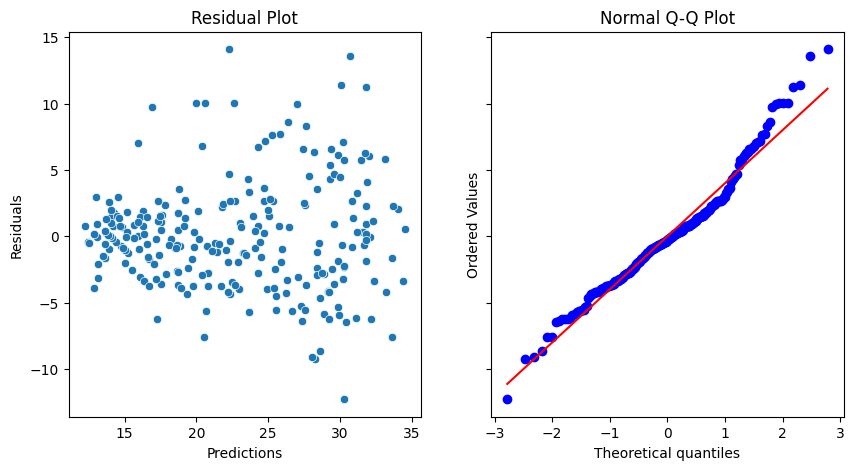

In [154]:
residual_analysis_plots(model)

In [155]:
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    mpg   R-squared:                       0.712
Model:                            OLS   Adj. R-squared:                  0.710
Method:                 Least Squares   F-statistic:                     311.9
Date:                Sun, 26 Oct 2025   Prob (F-statistic):           6.84e-69
Time:                        19:17:23   Log-Likelihood:                -717.45
No. Observations:                 255   AIC:                             1441.
Df Residuals:                     252   BIC:                             1452.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         61.3213      3.737     16.411      0.000      53.962      68.680
weight        -0.0182      0.002     -7.470      0.000      -0.023      -0.013
weight2     1.677e-06   3.74e-07      4.484      0.000    9.41e-07    2.41e-06
==============================================================================
Omnibus:                       22.257   Durbin-Watson:                   1.929
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               29.719
Skew:                           0.607   Prob(JB):                     3.52e-07
Kurtosis:                       4.150   Cond. No.                     1.68e+08
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.68e+08. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [156]:
model = sm.OLS(y, X).fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    mpg   R-squared:                       0.721
Model:                            OLS   Adj. R-squared:                  0.719
Method:                 Least Squares   F-statistic:                     407.5
Date:                Sun, 26 Oct 2025   Prob (F-statistic):           4.23e-88
Time:                        19:17:26   Log-Likelihood:                -907.69
No. Observations:                 318   AIC:                             1821.
Df Residuals:                     315   BIC:                             1833.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         63.7156      3.389     18.803      0.000      57.048      70.383
weight        -0.0193      0.002     -8.629      0.000      -0.024      -0.015
weight2     1.803e-06   3.48e-07      5.182      0.000    1.12e-06    2.49e-06
==============================================================================
Omnibus:                       36.516   Durbin-Watson:                   1.891
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               57.810
Skew:                           0.711   Prob(JB):                     2.80e-13
Kurtosis:                       4.531   Cond. No.                     1.58e+08
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.58e+08. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [157]:
new_data = pd.DataFrame({
    "weight":[5500,6633]
})

new_data_rev = new_data.assign(
    weight2= new_data["weight"]**2)


In [159]:
new_data_const = sm.add_constant(new_data_rev[features])
predicted_value = model.predict(new_data_const)
print(predicted_value)

0    12.001468
1    14.898494
dtype: float64


## Testing and Evaluation

In [133]:
print(f" Teat R2: {r2(y_val, model.predict(X_val))}")
print(f"Test MAE: {mae(y_val, model.predict(X_val))}")

 Teat R2: 0.847716022502383
Test MAE: 2.3035281511049246


In [130]:
from sklearn.preprocessing import StandardScaler

std = StandardScaler()

In [131]:
X_m = std.fit_transform(X.values)
X_te = std.fit(X_test.values)

In [140]:
from sklearn.linear_model import RidgeCV

n_alphas = 200
alphas = 10 ** np.linspace(-3, 3, n_alphas)

ridge_model = RidgeCV(alphas = alphas, cv = 5)
ridge_model.fit(X_m, y)

print(ridge_model.score(X_m,y))
print(mae(y,ridge_model.predict(X_m)))

print(ridge_model.alpha_)

0.8636076715003522
2.185175897898566
0.03001835813575589


In [141]:
print(f" Teat R2: {r2(y_test, model.predict(X_test))}")
print(f"Test MAE: {mae(y_test, model.predict(X_test))}")

 Teat R2: 0.8087480897721645
Test MAE: 2.2659313639801715
